###**RNN**

In [ ]:
# RNN Next Word Predictor using Alice in Wonderland Dataset

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
file = open("dataset.txt", "r", encoding="utf8")
text = file.read()
file.close()

text = text.lower()

print("Total characters in dataset:", len(text))

Total characters in dataset: 53073


In [ ]:
print(text[:500])

the project gutenberg ebook of alice's adventures in wonderland
    
i--down the rabbit-hole

alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do. once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, "and what is the use of a book," thought alice, "without pictures or
conversations?"

so she was considering in her own mind (as well as she could, for the
day made her feel very sleepy a


In [ ]:
# 2. Create Input Sequences (Word level vocabulary)
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Total words in vocabulary:", total_words)

Total words in vocabulary: 1538


In [ ]:
# 3. Create Training Sequences

input_sequences = []

for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Pad sequences
max_sequence_len = max([len(seq) for seq in input_sequences])

input_sequences = pad_sequences(input_sequences,
                                maxlen=max_sequence_len,
                                padding='pre')

# Split into predictors and label
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# One hot encoding of output
y = to_categorical(y, num_classes=total_words)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (8908, 16)
Output shape: (8908, 1538)


In [ ]:
# Reverse word index (index → word)
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

print("\nSample Training Examples:\n")

for i in range(5):   # print first 5 samples

    input_seq = X[i]
    target_word_index = np.argmax(y[i])   # because y is one-hot encoded

    # Convert input indices to words
    input_words = []
    for index in input_seq:
        if index != 0:  # ignore padding
            input_words.append(reverse_word_index.get(index, ""))

    target_word = reverse_word_index.get(target_word_index, "")

    print("Input :", " ".join(input_words))
    print("Next Word :", target_word)
    print("-----------------------")


Sample Training Examples:

Input : the
Next Word : project
-----------------------
Input : the project
Next Word : gutenberg
-----------------------
Input : the project gutenberg
Next Word : ebook
-----------------------
Input : the project gutenberg ebook
Next Word : of
-----------------------
Input : the project gutenberg ebook of
Next Word : alice's
-----------------------


In [ ]:
# 4. Build RNN Model
model = Sequential()

model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))

model.add(SimpleRNN(150))

model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Train the Model
history = model.fit(X, y,
                    epochs=50,
                    batch_size=128,
                    verbose=1)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0413 - loss: 6.5869
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0648 - loss: 5.8755
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0682 - loss: 5.7728
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0873 - loss: 5.5112
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1052 - loss: 5.3066
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1423 - loss: 5.0028
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1637 - loss: 4.7625
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1734 - loss: 4.5602
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2004 - loss: 4.2953
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2192 - loss: 4.1163
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2393 - loss: 3.9125
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2625 - l

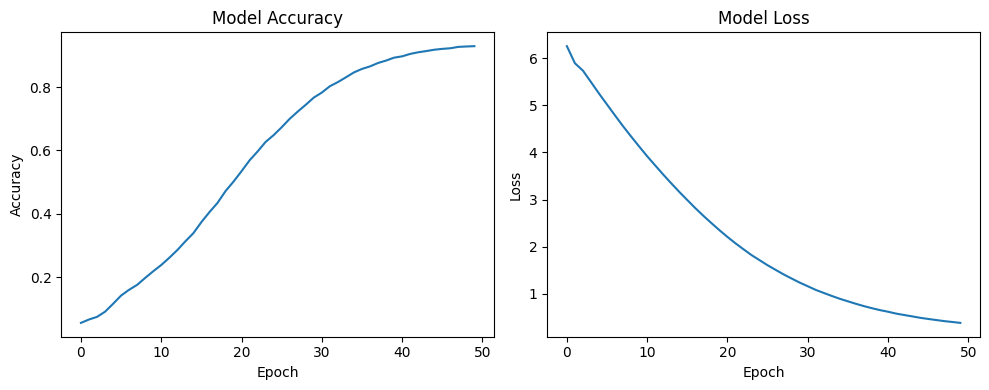

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [ ]:
# 6. Text Generation Function
def generate_text(seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences([token_list],
                                   maxlen=max_sequence_len-1,
                                   padding='pre')

        predicted = model.predict(token_list, verbose=0)

        predicted_word_index = np.argmax(predicted)

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text


In [ ]:
# 7. Generate New Text
print("\nGenerated Text:\n")

print(generate_text("alice was beginning", 20))


Generated Text:

alice was beginning to get very tired of sitting by her sister on the queen out of the window and the pair of


The RNN model was trained on the Alice in Wonderland dataset to predict the next word. The generated text shows patterns similar to the training data. The model successfully learns word sequences and generates text resembling the style of the dataset.

In [ ]:
import math

loss, accuracy = model.evaluate(X, y)
perplexity = math.exp(loss)

print("Accuracy:", accuracy)
print("Perplexity:", perplexity)

279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9384 - loss: 0.3406
Accuracy: 0.9387067556381226
Perplexity: 1.4027611358583343


* The trained RNN model achieved an accuracy of 93.87%, indicating that it correctly predicts the next word for most input sequences. The loss value of 0.3406 is low, showing that the model's predictions are close to the true target words. The perplexity value of 1.40 is also low, which means the language model is confident and effective at predicting the next word in the sequence. Overall, the model has successfully learned the word patterns from the Alice in Wonderland dataset and can generate text similar to the training data.

### **LSTM**

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
file = open("dataset.txt", "r", encoding="utf8")
text = file.read()
file.close()

text = text.lower()

print("Total characters:", len(text))

Total characters: 53073


In [ ]:
# 2. Create Vocabulary
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)

Vocabulary size: 1538


In [ ]:
# 3. Create Training Sequences
input_sequences = []

for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Padding

max_sequence_len = max([len(seq) for seq in input_sequences])

input_sequences = pad_sequences(input_sequences,
                                maxlen=max_sequence_len,
                                padding='pre')

# Predictors and Label

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print("Input shape:", X.shape)
print("Output shape:", y.shape)


Input shape: (8908, 16)
Output shape: (8908, 1538)


In [ ]:
# 4. Build LSTM Model
model = Sequential()

model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))

model.add(LSTM(150))

model.add(Dense(total_words, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Train Model
history = model.fit(
    X, y,
    epochs=50,
    batch_size=128,
    verbose=1
)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.0518 - loss: 6.7111
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0628 - loss: 5.8603
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0676 - loss: 5.7383
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0639 - loss: 5.6516
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0697 - loss: 5.5418
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0836 - loss: 5.4865
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0843 - loss: 5.4071
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1022 - loss: 5.2547
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1104 - loss: 5.2024
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1198 - loss: 5.1259
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1334 - loss: 5.0326
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1379 - l

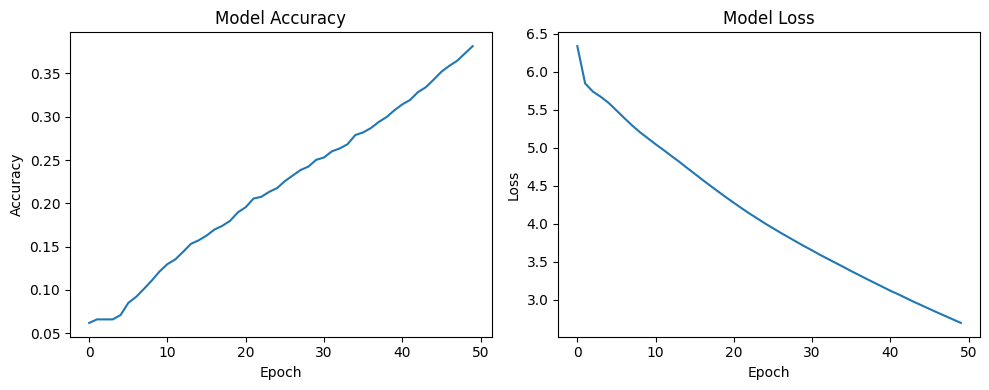

In [ ]:
# 6. Plot Accuracy and Loss
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [ ]:
# 7. Evaluation Metrics

loss, accuracy = model.evaluate(X, y)

perplexity = math.exp(loss)

print("\nEvaluation Metrics")
print("Accuracy:", accuracy)
print("Loss:", loss)
print("Perplexity:", perplexity)

279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3933 - loss: 2.6246

Evaluation Metrics
Accuracy: 0.4007633626461029
Loss: 2.5903377532958984
Perplexity: 13.334274537886037


In [ ]:
# 8. Text Generation Function

def generate_text(seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = model.predict(token_list, verbose=0)

        predicted_index = np.argmax(predicted)

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [ ]:
# 9. Generate New Text

print("\nGenerated Text:\n")

print(generate_text("alice was beginning", 20))


Generated Text:

alice was beginning to be a little pattering of the house and the other side of the other side of the other side


* The training graph shows that accuracy increases steadily with epochs, while loss decreases continuously, indicating that the LSTM model is learning the word sequence patterns from the dataset.
The model achieved an accuracy of about 40% with a loss of 2.59, which is acceptable for next-word prediction since the vocabulary size is large. The perplexity value of 13.33 suggests the model can reasonably predict the next word but still has some uncertainty.
The generated text follows a sentence-like structure and resembles the style of the Alice in Wonderland dataset, showing that the model has learned contextual word relationships.